# Validation_2: synthetic NK-cell decision trajectories

This notebook generates synthetic NK-cell contact histories with a two-layer model:

1. A Section 2-style Gamma-Poisson contact layer decides how many contacts each cell makes.
2. A history-dependent Bernoulli marking layer decides whether each contact is lethal.

The output is a row-wise history table where `0` is a non-lethal contact and `1` is a lethal contact.

In [1]:

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

from matplotlib import gridspec
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import NullLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import scienceplots
plt.style.use("science")

import arviz as az

NOTEBOOK_CWD = Path.cwd().resolve()

for candidate in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents]:
    SRC_DIR = candidate / "section_3" / "src"
    if (SRC_DIR / "simulator.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import simulator as sim
import inference as inf

FIGURE_DIR = PROJECT_ROOT / "section_3" / "figures" / "validation_2"
RESULT_DIR = PROJECT_ROOT / "section_3" / "results" / "validation_2"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
params = sim.ContactKillParams(
    n_cells=500,
    mean_lambda=3.0,
    sigma_lambda=1.0,
    p0=0.5,
    sigma_eta=0.8,
    beta_x=-1.0,
    beta_y=1.0,
    duration=1.0,
)

df = sim.simulate_contact_kill(params, seed=None, return_latent=True)
truth = sim.true_parameter_dict(params)

display(df.head())

,cell_id,history,n_contact,n_nonlethal,n_lethal,lambda,eta,p0
0,0,"(0, 1, 1, 0)",4,2,2,4.501682,-0.675864,0.337185
1,1,"(0, 0, 0, 1, 0)",5,4,1,3.681526,0.336508,0.583342
2,2,"(0, 1, 0, 0)",4,3,1,2.259250,0.749875,0.679151
3,3,"(1, 1)",2,0,2,2.854233,0.015692,0.503923
4,4,"(1, 1, 1)",3,0,3,3.745998,2.126142,0.893418


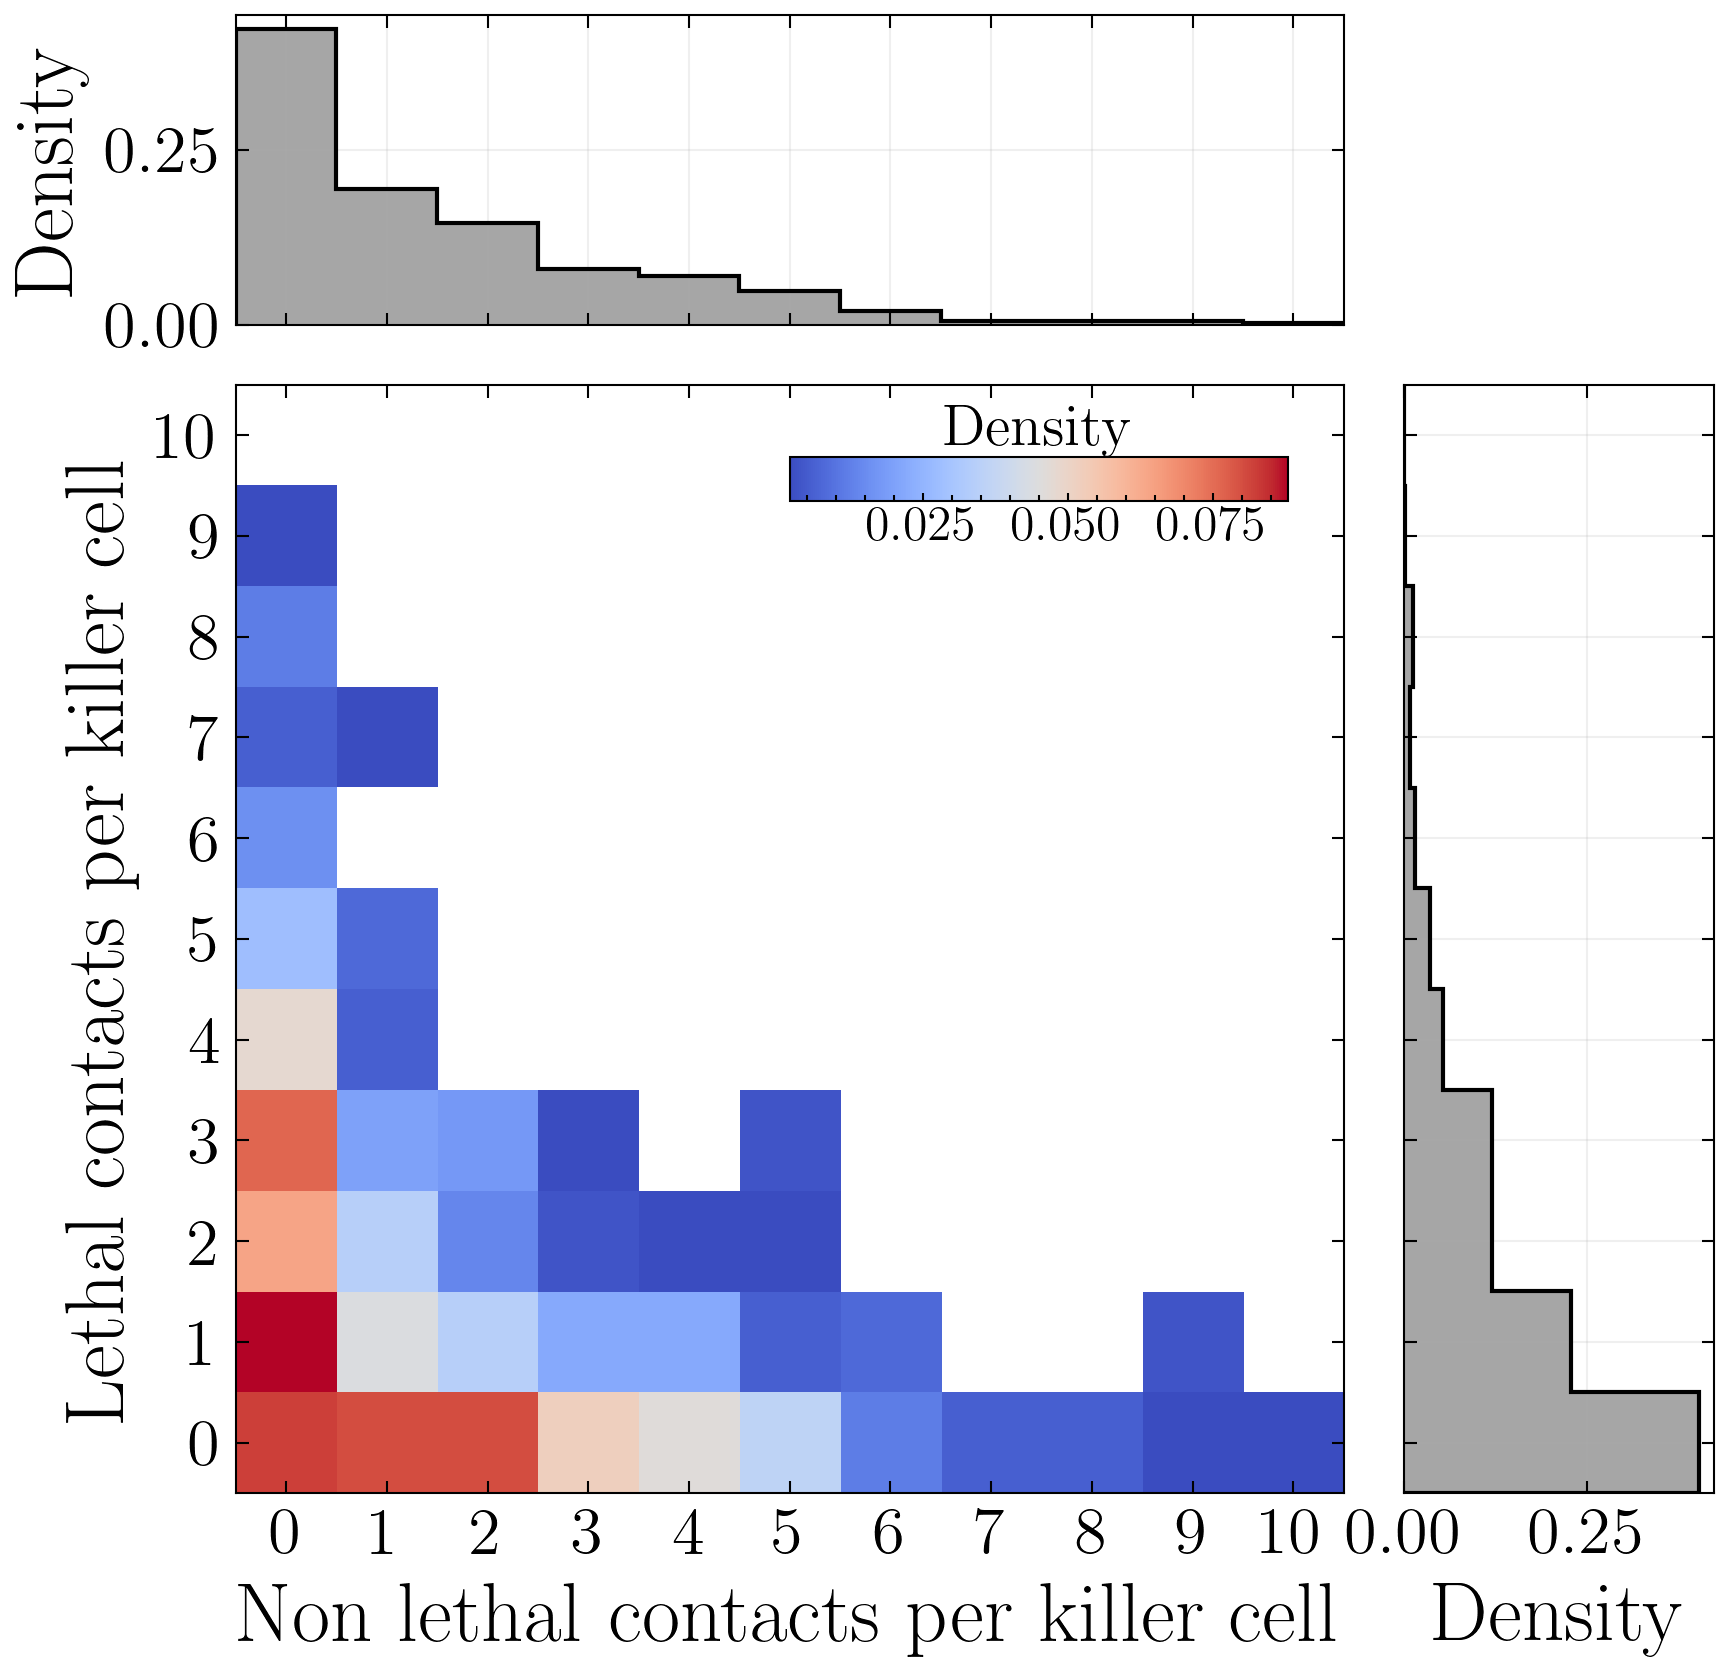

In [3]:
def history_to_path(history):
    history = np.asarray(history, dtype=int)
    path = np.zeros((history.size + 1, 2), dtype=float)

    for i, z in enumerate(history, start=1):
        path[i] = path[i - 1]

        if z == 1:
            path[i, 1] += 1
        else:
            path[i, 0] += 1

    return path


def histories_from_df(df):
    if "history" not in df:
        raise ValueError("df must contain a 'history' column.")

    return [tuple(h) for h in df["history"]]


def final_counts(data):
    histories = histories_from_df(data) if isinstance(data, pd.DataFrame) else data
    rows = []

    for cell_id, history in enumerate(histories):
        history = np.asarray(history, dtype=int)
        n_lethal = int(history.sum())
        n_nonlethal = int(history.size - n_lethal)

        rows.append(
            {
                "cell_id": cell_id,
                "history": tuple(history),
                "n_nonlethal": n_nonlethal,
                "n_lethal": n_lethal,
                "n_contact": n_nonlethal + n_lethal,
            }
        )

    return pd.DataFrame(rows)


def summarise_histories(data):
    df = final_counts(data) if not isinstance(data, pd.DataFrame) else data.copy()

    return {
        "n_cells": int(len(df)),
        "mean_contacts": float(df["n_contact"].mean()),
        "mean_kills": float(df["n_lethal"].mean()),
        "mean_nonlethal": float(df["n_nonlethal"].mean()),
        "fraction_no_contact": float((df["n_contact"] == 0).mean()),
        "fraction_no_kill": float((df["n_lethal"] == 0).mean()),
    }

def plot_traj_heatmap(
    data,
    *,
    mode="density",
    figsize=(7.2, 6.4),
    dpi=300,
    cmap="coolwarm",
    color="0",
    title=None,
):
    df = final_counts(data) if not isinstance(data, pd.DataFrame) else data.copy()

    x = df["n_nonlethal"].to_numpy(int)
    y = df["n_lethal"].to_numpy(int)

    max_value = int(max(x.max(initial=0), y.max(initial=0)))
    x_edges = np.arange(-0.5, max_value + 1.5, 1)
    y_edges = np.arange(-0.5, max_value + 1.5, 1)

    if mode == "count":
        H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
        hist_kwargs = {"density": False}
        cbar_label = "Count"
    elif mode == "frequency":
        H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
        H = H / H.sum() if H.sum() > 0 else H
        weights = np.ones_like(x, dtype=float) / len(x)
        hist_kwargs = {"weights": weights, "density": False}
        cbar_label = "Frequency"
    elif mode == "density":
        H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges], density=True)
        hist_kwargs = {"density": True}
        cbar_label = "Density"
    else:
        raise ValueError("mode must be 'frequency', 'count', or 'density'.")

    H = H.T
    H_masked = np.ma.masked_where(H == 0, H)

    fig, ax_main = plt.subplots(figsize=figsize, dpi=dpi)

    divider = make_axes_locatable(ax_main)
    ax_top = divider.append_axes("top", size="28%", pad=0.2, sharex=ax_main)
    ax_right = divider.append_axes("right", size="28%", pad=0.2, sharey=ax_main)

    im = ax_main.imshow(
        H_masked,
        origin="lower",
        cmap=cmap,
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        interpolation="nearest",
        aspect="equal",
    )

    cax = inset_axes(
        ax_main,
        width="45%",
        height="4%",
        loc="upper right",
        bbox_to_anchor=(-0.005, -0.02, 1, 1),
        bbox_transform=ax_main.transAxes,
        borderpad=1.2,
    )
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
    cbar.ax.set_title(cbar_label, fontsize=14, pad=2)
    cbar.ax.tick_params(labelsize=12, length=2, pad=1)

    ax_top.hist(x, bins=x_edges, color='black', histtype="step", **hist_kwargs)
    ax_top.hist(x, bins=x_edges, color=color, alpha=0.35, histtype="stepfilled", **hist_kwargs)
    ax_right.hist(y, bins=y_edges, orientation="horizontal",color='black', histtype="step", **hist_kwargs,)
    ax_right.hist(
        y,
        bins=y_edges,
        orientation="horizontal",
        color=color,
        alpha=0.35,
        **hist_kwargs,
    )

    ax_main.set_xlim(-0.5, max_value + 0.5)
    ax_main.set_ylim(-0.5, max_value + 0.5)

    ax_main.set_xlabel("Non lethal contacts per killer cell", fontsize=20)
    ax_main.set_ylabel("Lethal contacts per killer cell", fontsize=20)
    
    ax_top.set_ylabel(cbar_label, fontsize=20)
    ax_right.set_xlabel(cbar_label, fontsize=20)

    ax_main.xaxis.set_major_locator(MultipleLocator(1))
    ax_main.yaxis.set_major_locator(MultipleLocator(1))

    for ax in [ax_main, ax_top, ax_right]:
        ax.tick_params(axis="both", labelsize=16)
        ax.xaxis.set_minor_locator(NullLocator())
        ax.yaxis.set_minor_locator(NullLocator())
        ax.tick_params(which="minor", bottom=False, left=False, top=False, right=False)
        # ax.grid(True, alpha=0.2)
    for ax in [ax_top, ax_right]:
        ax.grid(True, alpha=0.2)

    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_right.get_yticklabels(), visible=False)

    if title:
        ax_top.set_title(title)

    stats = {
        "x_mean": float(np.mean(x)),
        "y_mean": float(np.mean(y)),
    }

    return fig, (ax_main, ax_top, ax_right), stats


fig, axes, stats = plot_traj_heatmap(
    df,
    mode="density",
    # title="Contacts and kills per NK cell",
)


**Bayesian inference**

In [4]:
history_data = inf.prepare_data(df)

print(history_data.n_cells)
print(history_data.n_contact[:10])
print(history_data.x_before[:10])
print(history_data.y_before[:10])
print(history_data.z[:10])

500
[4 5 4 2 3 0 3 3 3 1]
[0. 1. 1. 1. 0. 1. 2. 3. 3. 0.]
[0. 0. 1. 2. 0. 0. 0. 0. 1. 0.]
[0 1 1 0 0 0 0 1 0 0]


In [5]:
spec = inf.ModelSpec(
    name="heterogeneous_history_dependent",
    heterogeneous=True,
    history_dependent=True,
)

model = inf.build_model(
    history_data,
    spec,
    duration=params.duration,
    lambda_prior_bounds=(-5.0, 2.0),
    sigma_lambda_prior=1.0,
    p0_prior=(1.0, 1.0),
    sigma_eta_prior=1.0,
    beta_prior_sd=1.0,
    n_quad=30,
)

idata = inf.sample_smc(
    model,
    draws=4000,
    chains=4,
    cores=4,
    random_seed=None,
    prior_draws=1000,
    progressbar=True,
    retry_sequential=False, 
)

inf.posterior_summary(idata)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [beta_x, beta_y, eta_lambda, p0_centre, sigma_eta, sigma_lambda]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_lambda,3.022,0.090,2.855,3.190,0.001,0.001,14785.0,14669.0,1.0
sigma_lambda,0.993,0.142,0.724,1.257,0.001,0.001,15615.0,15406.0,1.0
p0_centre,0.499,0.026,0.452,0.547,0.000,0.000,15287.0,15686.0,1.0
mu_p0,0.499,0.026,0.452,0.547,0.000,0.000,15287.0,15686.0,1.0
mu_eta,-0.002,0.103,-0.194,0.189,0.001,0.001,15287.0,15686.0,1.0
sigma_eta,0.975,0.417,0.163,1.696,0.003,0.003,10078.0,4349.0,1.0
beta_x,-0.820,0.133,-1.060,-0.567,0.001,0.001,15498.0,15056.0,1.0
beta_y,0.882,0.138,0.618,1.131,0.001,0.001,15751.0,15212.0,1.0
odds_ratio_x,0.444,0.060,0.341,0.560,0.000,0.000,15498.0,15056.0,1.0
odds_ratio_y,2.437,0.329,1.814,3.046,0.003,0.002,15751.0,15212.0,1.0


In [6]:
PARAM_DISPLAY = {
    "mu_lambda": r"$\mu_\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
    "mu_p0": r"$p_{0,\mathrm{centre}}$",
    "mu_eta": r"$\mu_\eta$",
    "sigma_eta": r"$\sigma_\eta$",
    "beta_x": r"$\beta_x$",
    "beta_y": r"$\beta_y$",
    "odds_ratio_x": r"$\exp(\beta_x)$",
    "odds_ratio_y": r"$\exp(\beta_y)$",
}

def kde_contours(ax, x, y, *, color="#2F80ED", levels=(0.3, 0.5, 0.8, 0.95), gridsize=120):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if x.size < 5 or np.std(x) == 0 or np.std(y) == 0:
        ax.scatter(x, y, s=4, alpha=0.12, color=color, rasterized=True)
        return

    values = np.vstack([x, y])
    kde = gaussian_kde(values)

    x_pad = 0.08 * (x.max() - x.min())
    y_pad = 0.08 * (y.max() - y.min())

    xx, yy = np.mgrid[
        x.min() - x_pad : x.max() + x_pad : gridsize * 1j,
        y.min() - y_pad : y.max() + y_pad : gridsize * 1j,
    ]

    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    density = zz.ravel()
    order = np.argsort(density)[::-1]
    cumulative = np.cumsum(density[order])
    cumulative /= cumulative[-1]

    contour_levels = []
    for prob in levels:
        contour_levels.append(density[order][np.searchsorted(cumulative, prob)])

    contour_levels = np.sort(contour_levels)

    ax.contour(
        xx,
        yy,
        zz,
        levels=contour_levels,
        colors=color,
        linewidths=1.2,
        alpha=0.9,
    )

    ax.contourf(
        xx,
        yy,
        zz,
        levels=contour_levels,
        colors=[color],
        alpha=0.08,
    )


def posterior_samples_df(
    idata,
    parameters,
    *,
    sample_size=8000,
    seed=None,
):
    rng = np.random.default_rng(seed)
    rows = {}

    for param in parameters:
        if param not in idata.posterior:
            continue

        values = (
            idata.posterior[param]
            .stack(sample=("chain", "draw"))
            .values
            .ravel()
        )
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if values.size > sample_size:
            values = rng.choice(values, sample_size, replace=False)

        rows[param] = values

    min_len = min(len(v) for v in rows.values())
    rows = {k: v[:min_len] for k, v in rows.items()}

    return pd.DataFrame(rows)


def plot_section3_posteriors(
    idata,
    *,
    parameters=(
        "mu_lambda",
        "sigma_lambda",
        "p0_mean",
        "sigma_theta",
        "beta_x",
        "beta_y",
    ),
    truth=None,
    parameter_display=PARAM_DISPLAY,
    sample_size=8000,
    bins=35,
    figsize_per_param=2.5,
    color="#2F80ED",
    truth_color="black",
    dpi=300,
    save_path=None,
    title_fontsize = 28,
    tick_fontsize = 26,
):
    df_post = posterior_samples_df(
        idata,
        parameters,
        sample_size=sample_size,
    )

    parameters = list(df_post.columns)
    npar = len(parameters)

    fig, axes = plt.subplots(
        npar,
        npar,
        figsize=(figsize_per_param * npar, figsize_per_param * npar),
        dpi=dpi,
    )

    if npar == 1:
        axes = np.asarray([[axes]])

    for i, rowpar in enumerate(parameters):
        for j, colpar in enumerate(parameters):
            ax = axes[i, j]

            ax.xaxis.set_minor_locator(NullLocator())
            ax.yaxis.set_minor_locator(NullLocator())
            ax.tick_params(which="major", labelsize = tick_fontsize)

            if j > i:
                ax.axis("off")
                continue

            if i == j:
                values = df_post[rowpar].to_numpy()

                ax.hist(
                    values,
                    bins=bins,
                    density=True,
                    color=color,
                    alpha=0.35,
                    edgecolor=color,
                    linewidth=2,
                    histtype="step",
                )
                ax.hist(
                    values,
                    bins=bins,
                    density=True,
                    color=color,
                    alpha=0.35,
                    edgecolor=color,
                    histtype="stepfilled",
                )

                hdi = az.hdi(values, hdi_prob=0.95)
                mean = float(np.mean(values))

                # ax.axvline(mean, color=color, linewidth=2)
                ax.axvspan(hdi[0], hdi[1], color=color, alpha=0.12)

                if truth and rowpar in truth:
                    ax.axvline(
                        truth[rowpar],
                        color=truth_color,
                        linestyle="--",
                        linewidth=2,
                    )

                ax.set_ylabel("Density", fontsize=title_fontsize)

            else:
                ax.scatter(
                    df_post[colpar],
                    df_post[rowpar],
                    s=4,
                    alpha=0.12,
                    color=color,
                    rasterized=True,
                )
                kde_contours(
                    ax,
                    df_post[colpar],
                    df_post[rowpar],
                    color=color,
                )

                if truth:
                    if colpar in truth:
                        ax.axvline(
                            truth[colpar],
                            color=truth_color,
                            linestyle="--",
                            linewidth=1.5,
                        )
                    if rowpar in truth:
                        ax.axhline(
                            truth[rowpar],
                            color=truth_color,
                            linestyle="--",
                            linewidth=1.5,
                        )

            if i == npar - 1:
                ax.set_xlabel(parameter_display.get(colpar, colpar), fontsize=title_fontsize)
            else:
                plt.setp(ax.get_xticklabels(), visible=False)

            if j == 0 and i != j:
                ax.set_ylabel(parameter_display.get(rowpar, rowpar), fontsize=title_fontsize)
            elif i != j:
                plt.setp(ax.get_yticklabels(), visible=False)

            ax.grid(True, alpha=0.2)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path)

    return fig, axes, df_post

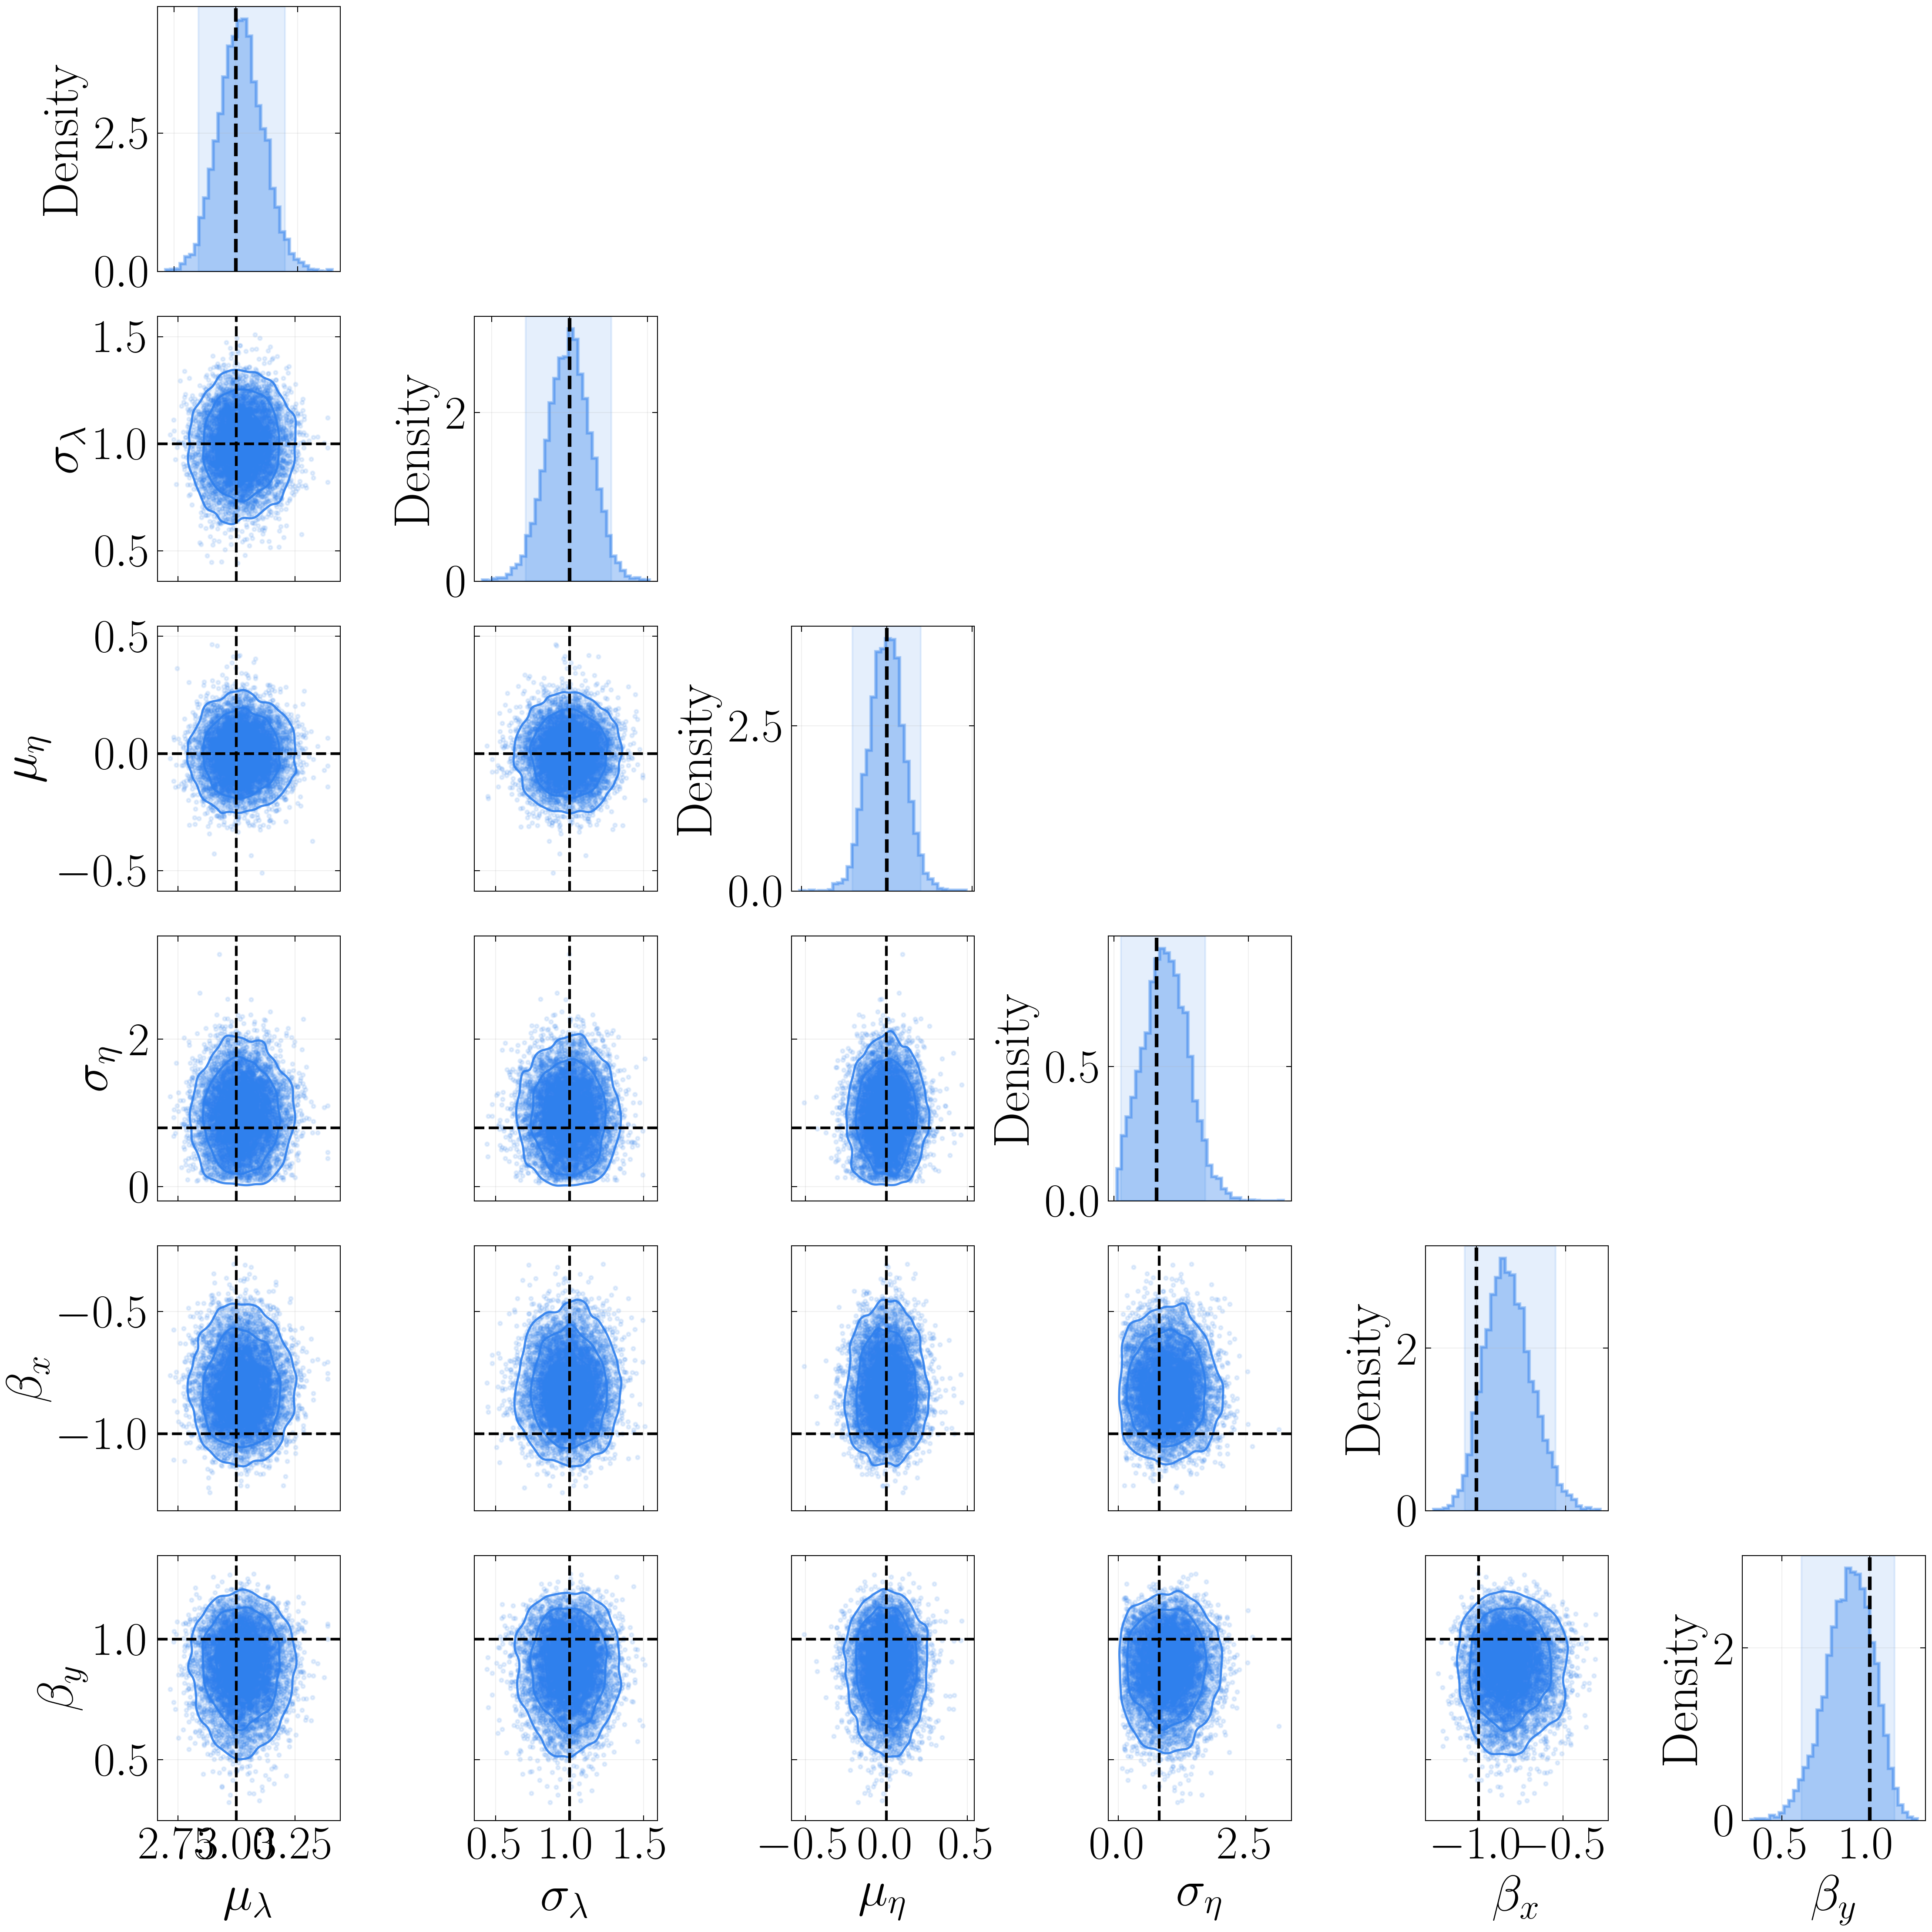

In [7]:
fig, axes, posterior_df = plot_section3_posteriors(
    idata,
    truth=truth,
    parameters=(
        "mu_lambda",
        "sigma_lambda",
        "mu_eta",
        "sigma_eta",
        "beta_x",
        "beta_y",
    ),
)